In [3]:
import sqlite3
import pandas as pd

# Load the CSV into a dataframe
df = pd.read_csv('Hospital_Readmissions_Reduction_Program.csv')

# Check what we're working with
print(df.shape)
print(df.columns.tolist())
print(df.head())

(18330, 12)
['Facility Name', 'Facility ID', 'State', 'Measure Name', 'Number of Discharges', 'Footnote', 'Excess Readmission Ratio', 'Predicted Readmission Rate', 'Expected Readmission Rate', 'Number of Readmissions', 'Start Date', 'End Date']
                     Facility Name  Facility ID State            Measure Name  \
0  SOUTHEAST HEALTH MEDICAL CENTER        10001    AL  READM-30-HIP-KNEE-HRRP   
1  SOUTHEAST HEALTH MEDICAL CENTER        10001    AL      READM-30-CABG-HRRP   
2  SOUTHEAST HEALTH MEDICAL CENTER        10001    AL       READM-30-AMI-HRRP   
3  SOUTHEAST HEALTH MEDICAL CENTER        10001    AL      READM-30-COPD-HRRP   
4  SOUTHEAST HEALTH MEDICAL CENTER        10001    AL        READM-30-PN-HRRP   

   Number of Discharges  Footnote  Excess Readmission Ratio  \
0                   NaN       NaN                    0.9875   
1                 137.0       NaN                    0.9531   
2                 273.0       NaN                    0.9370   
3               

In [5]:
# Clean the p column before loading
df['Number of Readmissions'] = pd.to_numeric(df['Number of Readmissions'], errors='coerce')

# Rename columns to be SQL friendly (no spaces)
df.columns = [
    'facility_name', 'facility_id', 'state', 'measure_name',
    'number_of_discharges', 'footnote', 'excess_readmission_ratio',
    'predicted_readmission_rate', 'expected_readmission_rate',
    'number_of_readmissions', 'start_date', 'end_date'
]

# Create SQLite database and load the data
conn = sqlite3.connect('hospital_readmissions.db')
df.to_sql('readmissions', conn, if_exists='replace', index=False)

print("Done! Rows loaded:", pd.read_sql("SELECT COUNT(*) as total FROM readmissions", conn).iloc[0,0])

Done! Rows loaded: 18330


In [7]:
# 1. Check distinct conditions
pd.read_sql("SELECT DISTINCT measure_name FROM readmissions", conn)

,measure_name
0,READM-30-HIP-KNEE-HRRP
1,READM-30-CABG-HRRP
2,READM-30-AMI-HRRP
3,READM-30-COPD-HRRP
4,READM-30-PN-HRRP
5,READM-30-HF-HRRP


In [9]:
# 2. Check for nulls in key columns
pd.read_sql("""
    SELECT 
        COUNT(*) as total_rows,
        SUM(CASE WHEN excess_readmission_ratio IS NULL THEN 1 ELSE 0 END) as null_ratios,
        SUM(CASE WHEN state IS NULL THEN 1 ELSE 0 END) as null_states,
        SUM(CASE WHEN number_of_readmissions IS NULL THEN 1 ELSE 0 END) as null_readmissions
    FROM readmissions
""", conn)

,total_rows,null_ratios,null_states,null_readmissions
0,18330,6610,0,10293


In [11]:
# 3. Check distinct states to make sure geography looks right
pd.read_sql("SELECT DISTINCT state FROM readmissions ORDER BY state", conn)

,state
0,AK
1,AL
2,AR
3,AZ
4,CA
5,CO
6,CT
7,DC
8,DE
9,FL


In [13]:
pd.read_sql("""
    SELECT 
        state,
        ROUND(AVG(excess_readmission_ratio), 4) as avg_excess_ratio,
        COUNT(DISTINCT facility_id) as num_hospitals
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY state
    ORDER BY avg_excess_ratio DESC
    LIMIT 15
""", conn)

,state,avg_excess_ratio,num_hospitals
0,MA,1.0344,52
1,NJ,1.0277,61
2,FL,1.0229,164
3,IL,1.0194,109
4,MS,1.0141,50
5,AL,1.0139,67
6,WV,1.0115,22
7,NV,1.0114,19
8,GA,1.0114,88
9,KY,1.0101,59


In [15]:
pd.read_sql("""
    SELECT 
        measure_name,
        ROUND(AVG(excess_readmission_ratio), 4) as avg_excess_ratio,
        ROUND(AVG(predicted_readmission_rate), 4) as avg_predicted_rate,
        COUNT(*) as num_hospitals
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY measure_name
    ORDER BY avg_excess_ratio DESC
""", conn)

,measure_name,avg_excess_ratio,avg_predicted_rate,num_hospitals
0,READM-30-HIP-KNEE-HRRP,1.0040,5.4913,1447
1,READM-30-CABG-HRRP,1.0018,10.6755,878
2,READM-30-AMI-HRRP,1.0018,13.4220,1736
3,READM-30-PN-HRRP,1.0015,15.5974,2715
4,READM-30-HF-HRRP,1.0014,19.3816,2621
5,READM-30-COPD-HRRP,1.0011,18.0014,2323


In [17]:
pd.read_sql("""
    SELECT 
        facility_name,
        state,
        measure_name,
        excess_readmission_ratio,
        RANK() OVER (PARTITION BY state ORDER BY excess_readmission_ratio DESC) as rank_in_state
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    ORDER BY state, rank_in_state
    LIMIT 20
""", conn)

,facility_name,state,measure_name,excess_readmission_ratio,rank_in_state
0,CENTRAL PENINSULA GENERAL HOSPITAL,AK,READM-30-HF-HRRP,1.2271,1
1,ALASKA REGIONAL HOSPITAL,AK,READM-30-HIP-KNEE-HRRP,1.1659,2
2,CENTRAL PENINSULA GENERAL HOSPITAL,AK,READM-30-COPD-HRRP,1.1171,3
3,ALASKA REGIONAL HOSPITAL,AK,READM-30-COPD-HRRP,1.1043,4
4,ALASKA REGIONAL HOSPITAL,AK,READM-30-HF-HRRP,1.0988,5
5,ALASKA REGIONAL HOSPITAL,AK,READM-30-PN-HRRP,1.0835,6
6,ALASKA REGIONAL HOSPITAL,AK,READM-30-CABG-HRRP,1.0817,7
7,MAT-SU REGIONAL MEDICAL CENTER,AK,READM-30-AMI-HRRP,1.0635,8
8,ALASKA NATIVE MEDICAL CENTER,AK,READM-30-HF-HRRP,1.0516,9
9,BARTLETT REGIONAL HOSPITAL,AK,READM-30-COPD-HRRP,1.0332,10


In [19]:
pd.read_sql("""
    SELECT 
        facility_name,
        state,
        measure_name,
        excess_readmission_ratio,
        CASE 
            WHEN excess_readmission_ratio > 1.10 THEN 'High Risk'
            WHEN excess_readmission_ratio BETWEEN 1.0 AND 1.10 THEN 'Above Average'
            WHEN excess_readmission_ratio BETWEEN 0.90 AND 1.0 THEN 'Below Average'
            ELSE 'Low Risk'
        END as performance_tier
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    ORDER BY excess_readmission_ratio DESC
    LIMIT 20
""", conn)

,facility_name,state,measure_name,excess_readmission_ratio,performance_tier
0,FAIRFIELD MEDICAL CENTER,OH,READM-30-HIP-KNEE-HRRP,1.6297,High Risk
1,CARLE BROMENN MEDICAL CENTER,IL,READM-30-HIP-KNEE-HRRP,1.5827,High Risk
2,HOLY FAMILY HOSPITAL,MA,READM-30-HIP-KNEE-HRRP,1.5658,High Risk
3,BROWN UNIVERSITY HEALTH MORTON HOSPITAL,MA,READM-30-HIP-KNEE-HRRP,1.5594,High Risk
4,GREAT PLAINS REGIONAL MEDICAL CENTER,OK,READM-30-HIP-KNEE-HRRP,1.5367,High Risk
5,SAINT FRANCIS HOSPITAL MUSKOGEE,OK,READM-30-HIP-KNEE-HRRP,1.5217,High Risk
6,HCA FLORIDA OAK HILL HOSPITAL,FL,READM-30-HIP-KNEE-HRRP,1.5196,High Risk
7,ST MARY'S HOSPITAL,GA,READM-30-HIP-KNEE-HRRP,1.5095,High Risk
8,GOOD SAMARITAN MEDICAL CENTER,FL,READM-30-HIP-KNEE-HRRP,1.4908,High Risk
9,ECU HEALTH MEDICAL CENTER,NC,READM-30-HIP-KNEE-HRRP,1.4851,High Risk


In [21]:
pd.read_sql("""
    WITH hospital_avg AS (
        SELECT 
            facility_name,
            state,
            ROUND(AVG(excess_readmission_ratio), 4) as avg_ratio,
            COUNT(DISTINCT measure_name) as conditions_tracked
        FROM readmissions
        WHERE excess_readmission_ratio IS NOT NULL
        GROUP BY facility_name, state
    )
    SELECT *
    FROM hospital_avg
    WHERE conditions_tracked >= 3
    ORDER BY avg_ratio DESC
    LIMIT 15
""", conn)

,facility_name,state,avg_ratio,conditions_tracked
0,OROVILLE HOSPITAL,CA,1.2484,5
1,WINCHESTER HOSPITAL,MA,1.2212,5
2,ST LUCIE MEDICAL CENTER,FL,1.2014,5
3,"NEW YORK COMMUNITY HOSPITAL OF BROOKLYN, INC.",NY,1.1778,3
4,ALLIANCEHEALTH DURANT,OK,1.1735,5
5,BROWN UNIVERSITY HEALTH MORTON HOSPITAL,MA,1.1715,5
6,GREAT PLAINS REGIONAL MEDICAL CENTER,OK,1.1650,3
7,ST JOHN'S EPISCOPAL HOSPITAL AT SOUTH SHORE,NY,1.1635,3
8,STURDY MEMORIAL HOSPITAL,MA,1.1569,4
9,HOLY FAMILY HOSPITAL,MA,1.1552,5


In [23]:
pd.read_sql("""
    SELECT 
        state,
        measure_name,
        ROUND(AVG(predicted_readmission_rate - expected_readmission_rate), 4) as avg_rate_gap,
        ROUND(AVG(excess_readmission_ratio), 4) as avg_excess_ratio,
        COUNT(DISTINCT facility_id) as num_hospitals
    FROM readmissions
    WHERE predicted_readmission_rate IS NOT NULL
    AND expected_readmission_rate IS NOT NULL
    GROUP BY state, measure_name
    ORDER BY avg_rate_gap DESC
    LIMIT 20
""", conn)

,state,measure_name,avg_rate_gap,avg_excess_ratio,num_hospitals
0,WY,READM-30-CABG-HRRP,0.9722,1.1084,2
1,MA,READM-30-AMI-HRRP,0.7102,1.0512,33
2,MA,READM-30-PN-HRRP,0.6916,1.0458,51
3,MA,READM-30-HF-HRRP,0.6584,1.0361,51
4,NJ,READM-30-PN-HRRP,0.6443,1.0383,61
5,MA,READM-30-COPD-HRRP,0.6148,1.0357,49
6,RI,READM-30-AMI-HRRP,0.6053,1.0436,4
7,WV,READM-30-HF-HRRP,0.6048,1.0290,21
8,TN,READM-30-CABG-HRRP,0.5800,1.0613,20
9,FL,READM-30-HF-HRRP,0.5662,1.0280,161


In [25]:
pd.read_sql("""
    SELECT 
        measure_name,
        CASE 
            WHEN excess_readmission_ratio > 1.10 THEN 'High Risk'
            WHEN excess_readmission_ratio BETWEEN 1.0 AND 1.10 THEN 'Above Average'
            WHEN excess_readmission_ratio BETWEEN 0.90 AND 1.0 THEN 'Below Average'
            ELSE 'Low Risk'
        END as performance_tier,
        COUNT(*) as num_hospitals,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY measure_name), 2) as pct_of_condition
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY measure_name, performance_tier
    ORDER BY measure_name, pct_of_condition DESC
""", conn)

,measure_name,performance_tier,num_hospitals,pct_of_condition
0,READM-30-AMI-HRRP,Below Average,778,44.82
1,READM-30-AMI-HRRP,Above Average,747,43.03
2,READM-30-AMI-HRRP,High Risk,115,6.62
3,READM-30-AMI-HRRP,Low Risk,96,5.53
4,READM-30-CABG-HRRP,Above Average,323,36.79
5,READM-30-CABG-HRRP,Below Average,313,35.65
6,READM-30-CABG-HRRP,Low Risk,126,14.35
7,READM-30-CABG-HRRP,High Risk,116,13.21
8,READM-30-COPD-HRRP,Below Average,1202,51.74
9,READM-30-COPD-HRRP,Above Average,1033,44.47


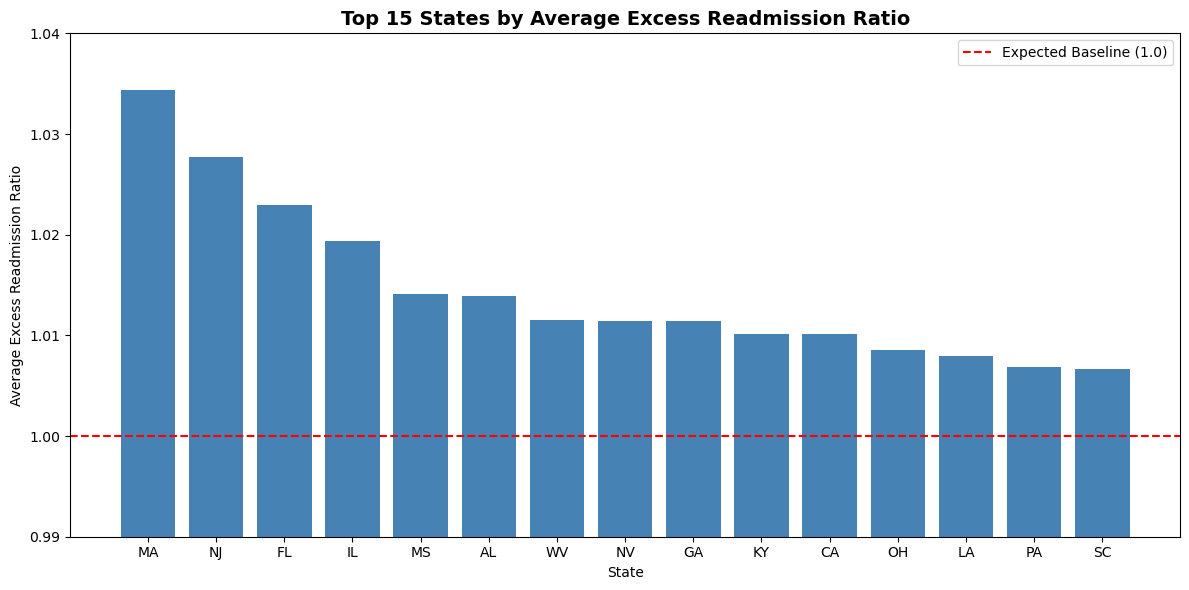

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pull the data from Query 1
state_data = pd.read_sql("""
    SELECT 
        state,
        ROUND(AVG(excess_readmission_ratio), 4) as avg_excess_ratio,
        COUNT(DISTINCT facility_id) as num_hospitals
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY state
    ORDER BY avg_excess_ratio DESC
    LIMIT 15
""", conn)

plt.figure(figsize=(12, 6))
bars = plt.bar(state_data['state'], state_data['avg_excess_ratio'], color='steelblue')
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Expected Baseline (1.0)')
plt.title('Top 15 States by Average Excess Readmission Ratio', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Average Excess Readmission Ratio')
plt.ylim(0.99, 1.04)  # Zoom in to make differences visible
plt.legend()
plt.tight_layout()
plt.savefig('chart1_states.png', dpi=150)
plt.show()

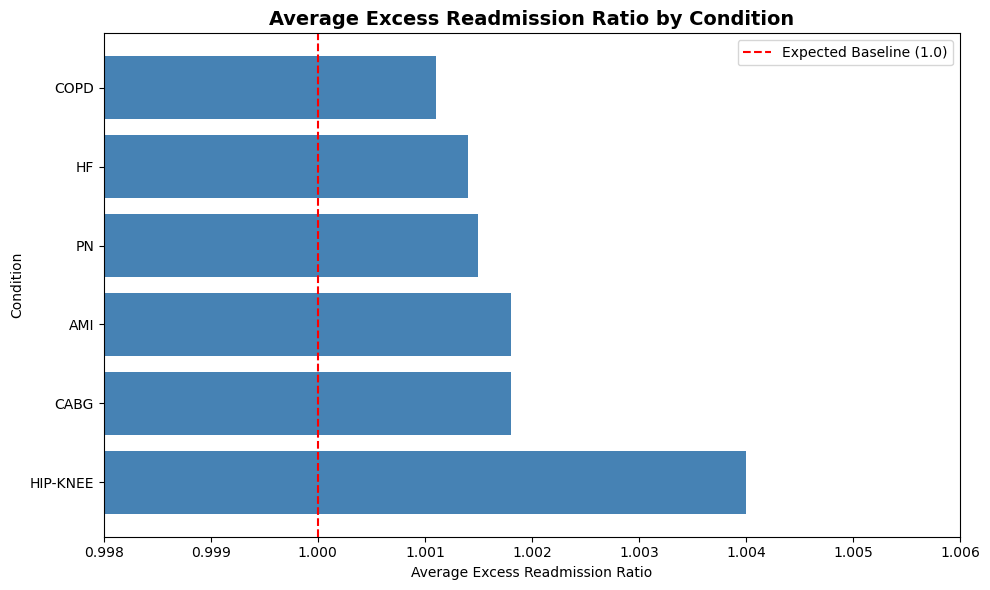

In [29]:
# Pull condition data from Query 2
condition_data = pd.read_sql("""
    SELECT 
        measure_name,
        ROUND(AVG(excess_readmission_ratio), 4) as avg_excess_ratio,
        ROUND(AVG(predicted_readmission_rate), 4) as avg_predicted_rate
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY measure_name
    ORDER BY avg_excess_ratio DESC
""", conn)

# Clean up measure names for readability
condition_data['measure_name'] = condition_data['measure_name'].str.replace('READM-30-', '').str.replace('-HRRP', '')

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(condition_data['measure_name'], condition_data['avg_excess_ratio'], color='steelblue')
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Expected Baseline (1.0)')
plt.title('Average Excess Readmission Ratio by Condition', fontsize=14, fontweight='bold')
plt.xlabel('Average Excess Readmission Ratio')
plt.ylabel('Condition')
plt.xlim(0.998, 1.006)
plt.legend()
plt.tight_layout()
plt.savefig('chart2_conditions.png', dpi=150)
plt.show()

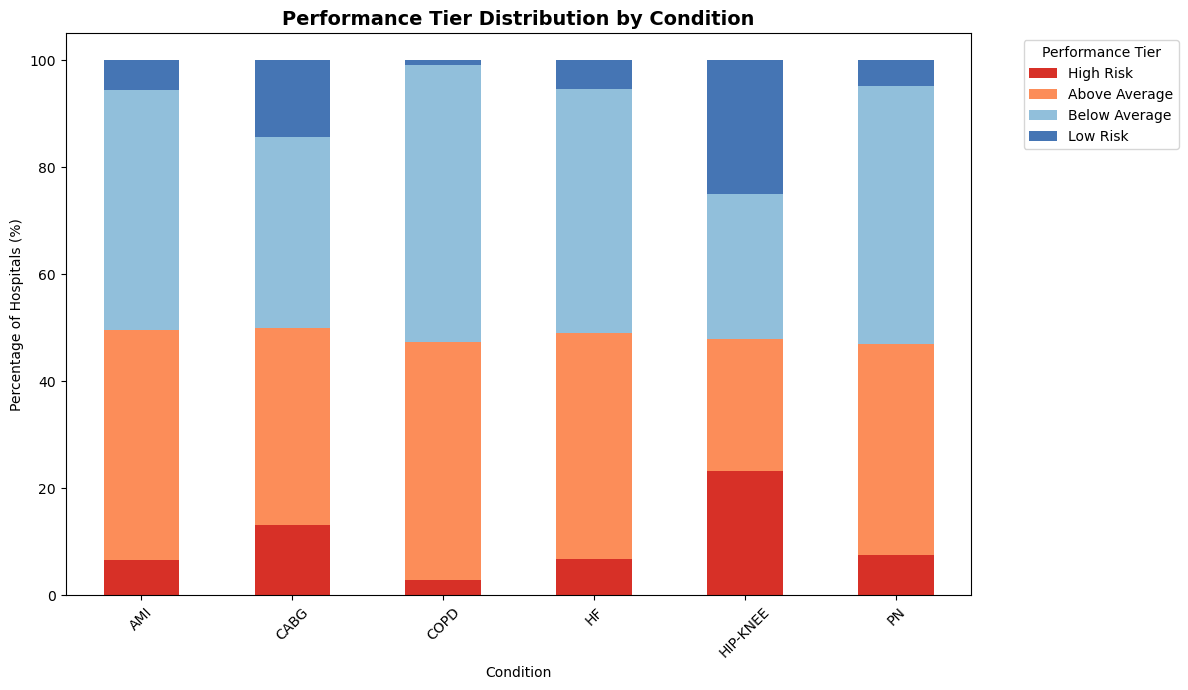

In [31]:
# Pull tier distribution data
tier_data = pd.read_sql("""
    SELECT 
        measure_name,
        CASE 
            WHEN excess_readmission_ratio > 1.10 THEN 'High Risk'
            WHEN excess_readmission_ratio BETWEEN 1.0 AND 1.10 THEN 'Above Average'
            WHEN excess_readmission_ratio BETWEEN 0.90 AND 1.0 THEN 'Below Average'
            ELSE 'Low Risk'
        END as performance_tier,
        COUNT(*) as num_hospitals,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY measure_name), 2) as pct_of_condition
    FROM readmissions
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY measure_name, performance_tier
    ORDER BY measure_name, pct_of_condition DESC
""", conn)

# Clean up measure names
tier_data['measure_name'] = tier_data['measure_name'].str.replace('READM-30-', '').str.replace('-HRRP', '')

# Pivot for stacked bar chart
tier_pivot = tier_data.pivot(index='measure_name', columns='performance_tier', values='pct_of_condition').fillna(0)

# Order the tiers logically
tier_order = ['High Risk', 'Above Average', 'Below Average', 'Low Risk']
tier_pivot = tier_pivot[tier_order]

# Plot
colors = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4']
tier_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), color=colors)
plt.title('Performance Tier Distribution by Condition', fontsize=14, fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Percentage of Hospitals (%)')
plt.xticks(rotation=45)
plt.legend(title='Performance Tier', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart3_tiers.png', dpi=150)
plt.show()